In [ ]:
!pip install scikit-learn
from sklearn.datasets import fetch_openml
# fetch_openml returns a Bunch object which has data and target attributes
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
# the data and target are now accessed as follows:
X, y = mnist["data"], mnist["target"]

In [ ]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [ ]:
x, y = mnist["data"], mnist["target"]

In [ ]:
x.shape

(70000, 784)

In [ ]:
y.shape

(70000,)

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
some_digit = x[3601]
some_digit_image = some_digit.reshape(28, 28)

(-0.5, 27.5, 27.5, -0.5)

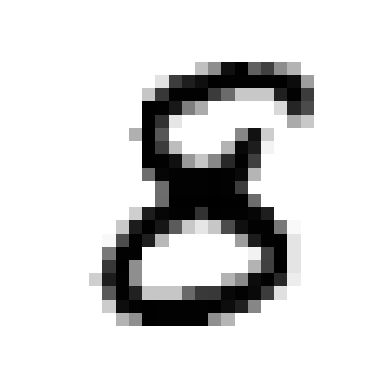

In [ ]:
plt.imshow(some_digit_image, cmap = matplotlib.cm.binary, interpolation="nearest")
plt.axis("off")


In [ ]:
y[3601]

'8'

In [ ]:
x_train, x_test, y_train, y_test = x[0:6000], x[6000:7000], y[0:6000], y[6000:7000]

In [ ]:
import numpy as np
shuffle_index = np.random.permutation(6000)
x_train, y_train = x_train[shuffle_index], y_train[shuffle_index]

# **Creating a 2 detector**

In [ ]:
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

In [ ]:
y_train

array([7, 4, 8, ..., 9, 9, 6], dtype=int8)

In [ ]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(tol = 0.1, solver='lbfgs')
clf.fit(x_train, y_train_2)

LogisticRegression(tol=0.1)

In [ ]:
clf.predict([some_digit])

array([False])

In [ ]:
a.mean()

0.9568333333333333

Confusion Matrix:
 [[885  21]
 [ 13  81]]


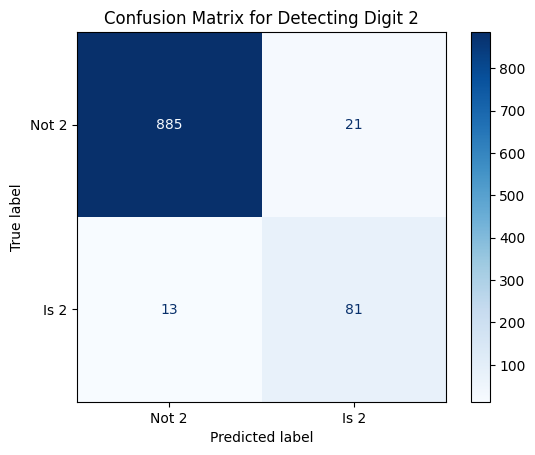

Cross-validation scores: [0.961  0.953  0.9565]
Mean cross-validation score: 0.9568333333333333


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# Split data into train and test sets (using the same split as before)
x_train, x_test, y_train, y_test = X[0:6000], X[6000:7000], y[0:6000], y[6000:7000]

# Shuffle the training data
shuffle_index = np.random.permutation(6000)
x_train, y_train = x_train[shuffle_index], y_train[shuffle_index]

# Convert labels to integers and create binary labels for '2'
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

# Train the Logistic Regression model
clf = LogisticRegression(tol=0.1, solver='lbfgs')
clf.fit(x_train, y_train_2)

# Make predictions on the test set
y_pred = clf.predict(x_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test_2, y_pred)
print("Confusion Matrix:\n", cm)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not 2', 'Is 2'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Detecting Digit 2')
plt.show()


# Calculate cross-validation scores
a = cross_val_score(clf, x_train, y_train_2, cv=3, scoring="accuracy")
print(f"Cross-validation scores: {a}")
print(f"Mean cross-validation score: {a.mean()}")

In [ ]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, brier_score_loss

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# Split data into train and test sets
x_train, x_test, y_train, y_test = X[0:6000], X[6000:7000], y[0:6000], y[6000:7000]

# Shuffle the training data
shuffle_index = np.random.permutation(6000)
x_train, y_train = x_train[shuffle_index], y_train[shuffle_index]

# Convert labels to integers and create binary labels for '2'
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

# Train the Logistic Regression model
clf = LogisticRegression(tol=0.1, solver='lbfgs')
clf.fit(x_train, y_train_2)

# Get predicted probabilities for the test set
y_pred_proba = clf.predict_proba(x_test)[:, 1] # Probability of being class '2'

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_2, y_pred_proba))
print(f"RMSE: {rmse}")

# Calculate Brier Score
brier = brier_score_loss(y_test_2, y_pred_proba)
print(f"Brier Score: {brier}")

RMSE: 0.17192389715785983
Brier Score: 0.02955782641394636


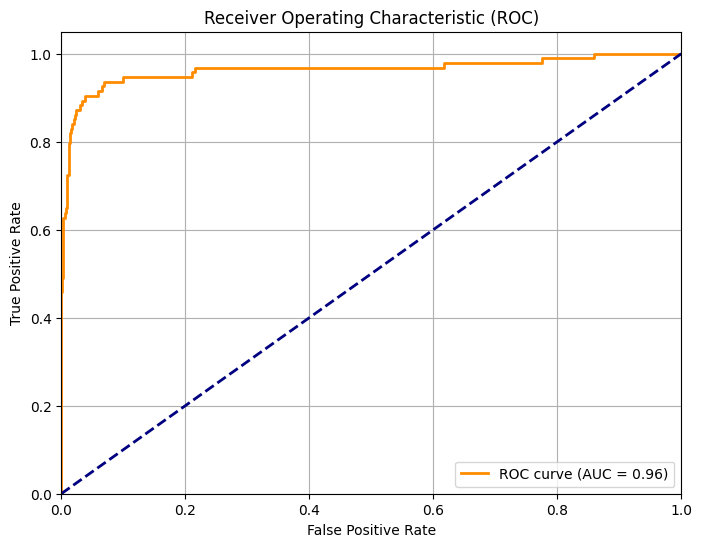

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# Split data into train and test sets
x_train, x_test, y_train, y_test = X[0:6000], X[6000:7000], y[0:6000], y[6000:7000]

# Shuffle the training data
shuffle_index = np.random.permutation(6000)
x_train, y_train = x_train[shuffle_index], y_train[shuffle_index]


# Convert labels to integers and create binary labels for '2'
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

# Train the Logistic Regression model
clf = LogisticRegression(tol=0.1, solver='lbfgs')
clf.fit(x_train, y_train_2)

# Get predicted probabilities for the test set
y_pred_proba = clf.predict_proba(x_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test_2, y_pred_proba)
roc_auc = roc_auc_score(y_test_2, y_pred_proba)


# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid()
plt.show()

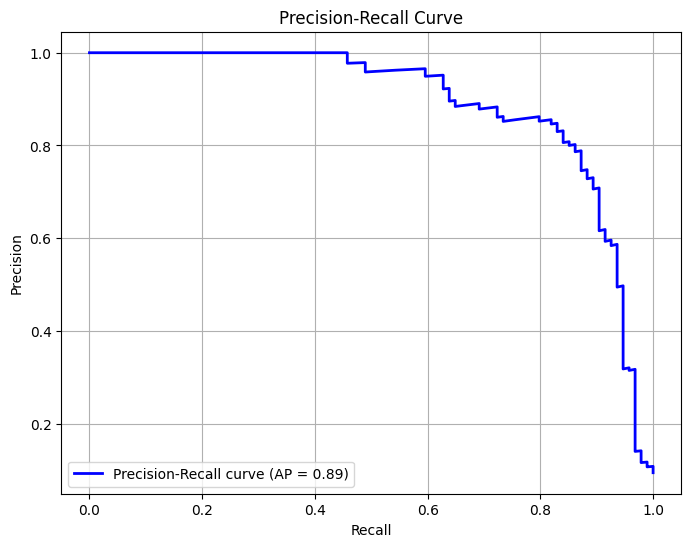

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, average_precision_score


# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# Split data into train and test sets
x_train, x_test, y_train, y_test = X[0:6000], X[6000:7000], y[0:6000], y[6000:7000]

# Shuffle the training data
shuffle_index = np.random.permutation(6000)
x_train, y_train = x_train[shuffle_index], y_train[shuffle_index]


# Convert labels to integers and create binary labels for '2'
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

# Train the Logistic Regression model
clf = LogisticRegression(tol=0.1, solver='lbfgs')
clf.fit(x_train, y_train_2)

# Get predicted probabilities for the test set
y_pred_proba = clf.predict_proba(x_test)[:, 1]

# Calculate precision-recall curve and average precision score
precision, recall, thresholds = precision_recall_curve(y_test_2, y_pred_proba)
average_precision = average_precision_score(y_test_2, y_pred_proba)

# Plot precision-recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'Precision-Recall curve (AP = {average_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.grid()
plt.show()

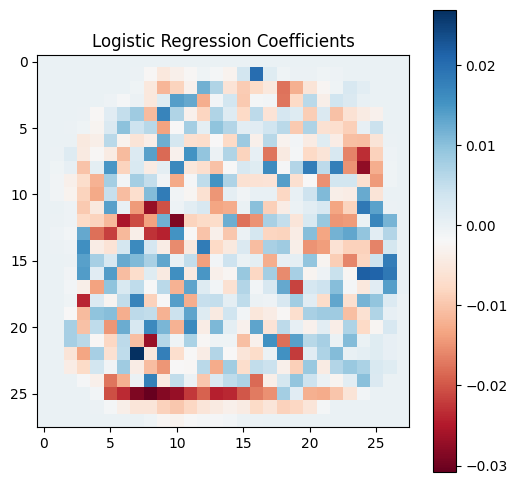

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression

# Load the MNIST dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist["data"], mnist["target"]

# Split data into train and test sets
x_train, x_test, y_train, y_test = X[0:6000], X[6000:7000], y[0:6000], y[6000:7000]

# Shuffle the training data
shuffle_index = np.random.permutation(6000)
x_train, y_train = x_train[shuffle_index], y_train[shuffle_index]


# Convert labels to integers and create binary labels for '2'
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
y_train_2 = (y_train == 2)
y_test_2 = (y_test == 2)

# Train the Logistic Regression model
clf = LogisticRegression(tol=0.1, solver='lbfgs')
clf.fit(x_train, y_train_2)


# Get the coefficients
coefficients = clf.coef_.reshape(28, 28)

# Plot coefficients as an image
plt.figure(figsize=(6,6))
plt.imshow(coefficients, cmap='RdBu')
plt.title("Logistic Regression Coefficients")
plt.colorbar()
plt.show()

# **Quiz**

In [ ]:

import random

def classify_digit(digit):
    """
    Classifies a digit, with a 90% probability of classifying it as "not 2".

    Args:
        digit: The digit to classify (assumed to be an integer).

    Returns:
        "not 2" with 90% probability, otherwise "2".
    """

    if random.random() < 0.9:
        return "not 2"